## NeRF

Необходимо реализовать базовую версию [NeRF](https://arxiv.org/pdf/2003.08934.pdf) не включающую иерархический семплинг (его тоже можно реализовать, если есть желание)

In [1]:
%%bash

# Download dataset and helper library
for part in data lib; do
    if [ ! -d "${part}/" ]; then
        curl -sO "https://code.mipt.ru/courses-public/cv/storage/-/raw/tasks/neural-radiance-fields/${part}.zip"
        unzip -qo "${part}.zip"
    fi
done

# Install required dependencies
if ! pip freeze | grep -q nvdiffrast; then
    pip install -q \
        git+https://github.com/NVlabs/nvdiffrast.git \
        ninja xatlas trimesh \
        torch matplotlib
fi

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import nvdiffrast.torch as dr
import torch
import torch.nn as nn

glctx = dr.RasterizeCudaContext()

In [3]:
from lib.dataset import DatasetNERF

dataset = DatasetNERF(
    cfg="./data/hotdog/transforms_train.json",
    near=2.0,
    far=6.0,
    resolution=(160, 160),
    ray_mode=True,
)

In [39]:
def ray_gen(imv, coords, focal, resolution):
    """
    Необходимо реализовать функцию генерации лучей по заданным параметрам камеры

        @params: imv -- матрица 4x4, преобразование Camera Frame -> World Frame
        @params: coords -- координаты пикселя, coords[..., 0] - w, coords[..., 1] - h
        @params: focal -- фокальное расстояние камеры
        @params: resolution -- H, W разрешение

        Return: rays_o, rays_d -- положение и направление лучей
    """
    H, W = resolution
    device = imv.device

    # Проверка на размерность [N, 4, 4]
    if imv.dim() == 2:
        imv = imv.unsqueeze(0)

    N_rays = coords.shape[0]
    N_cam = imv.shape[0]

    coords = coords.to(device)

    # Создаем направления лучей в системе координат камеры
    x = (coords[:, 0].float() + 0.5 - W * 0.5) / focal
    y = -(coords[:, 1].float() + 0.5 - H * 0.5) / focal
    z = -torch.ones(N_rays, device=device)
    dirs = torch.stack([x, y, z], dim=-1)

    R = imv[:, :3, :3]
    T = imv[:, :3, 3]

    # Если камера одна (режим рендера), размножаем матрицы на количество лучей
    if N_cam == 1:
        R = R.expand(N_rays, -1, -1)
        T = T.expand(N_rays, -1)

    rays_d = torch.bmm(dirs.unsqueeze(1), R.transpose(1, 2)).squeeze(1)
    rays_d = rays_d / torch.norm(rays_d, dim=-1, keepdim=True)

    # Начало лучей
    rays_o = T

    return rays_o, rays_d

In [40]:
def ray_color(
    ray_o,
    ray_d,
    radiance_field_fn,
    near,
    far,
    bins,
    chunk=8192
):
    """
    Необходимо реализовать функцию рендеринга лучей, согласно уравнению NeRF'a: https://arxiv.org/pdf/2003.08934.pdf

        @params: ray_o, ray_d -- положение и направления луча
        @params: radiance_field_fn -- функция, возврашающая color, sigma
        @params: near, far -- диапазон семплирования вдоль лучей
        @params: bins -- количество точек для семплирования

        Return: color -- интегрированный по лучам свет
    """
    device = ray_o.device
    t_vals = torch.linspace(near, far, bins, device=device)
    t_vals = t_vals.expand(ray_o.shape[0], bins)

    # Для устранения полос
    mids = 0.5 * (t_vals[:, :-1] + t_vals[:, 1:])
    upper = torch.cat([mids, t_vals[:, -1:]], dim=-1)
    lower = torch.cat([t_vals[:, :1], mids], dim=-1)
    t_rand = torch.rand(t_vals.shape, device=device)
    t_vals = lower + (upper - lower) * t_rand

    pts = ray_o.unsqueeze(1) + ray_d.unsqueeze(1) * t_vals.unsqueeze(-1)
    pts_flat = pts.reshape(-1, 3)

    raw = []
    for i in range(0, pts_flat.shape[0], chunk):
        raw.append(radiance_field_fn(pts_flat[i:i+chunk]))
    raw = torch.cat(raw, dim=0).reshape(ray_o.shape[0], bins, 4)

    rgb = torch.sigmoid(raw[..., :3])
    # relu + epsilon (стабилизация)
    sigma = torch.relu(raw[..., 3]) # + 1e-7

    deltas = t_vals[:, 1:] - t_vals[:, :-1]
    deltas = torch.cat([deltas, torch.tensor([1e10], device=device).expand(deltas.shape[0], 1)], dim=-1)
    alpha = 1.0 - torch.exp(-sigma * deltas)

    T = torch.cumprod(torch.cat([
      torch.ones((alpha.shape[0], 1), device=device),
      1.0 - alpha + 1e-10
    ], dim=-1), dim=-1)[:, :-1]

    weights = alpha * T
    color = (weights.unsqueeze(-1) * rgb).sum(dim=1)
    return color

In [41]:
from functools import partial

def render_radiance_field(
    imv,
    coords,
    radiance_field_fn,
    focal,
    resolution,
    near=2.0,
    far=6.0,
    bins=64,
    train=True,
    chunk=1024,
):
    ray_gen_ = partial(ray_gen, focal=focal, resolution=resolution)
    ray_color_ = partial(ray_color, radiance_field_fn=radiance_field_fn, near=near, far=far, bins=bins)

    imv = (
        torch.tensor(imv, dtype=torch.float32, device="cuda")
        if not torch.is_tensor(imv)
        else imv
    )

    if train:
        ray_o, ray_d = ray_gen_(imv, coords)
        color = ray_color_(ray_o, ray_d)
        return color

    with torch.no_grad():
        H, W = resolution
        u, v = torch.meshgrid(
            torch.linspace(0, H - 1, H),
            torch.linspace(0, W - 1, W),
            indexing="ij",
        )
        coords = torch.stack([v.flatten(), u.flatten()], dim=-1)

        # Передаем камеру с размером [1, 4, 4]
        ray_o, ray_d = ray_gen_(imv[0:1, ...], coords)
        ray_o = ray_o.expand([ray_d.shape[0], -1])

        steps = ray_o.shape[0] // chunk + (ray_o.shape[0] % chunk > 0)
        color = torch.cat(
            [
                ray_color_(
                    ray_o[i * chunk : (i + 1) * chunk],
                    ray_d[i * chunk : (i + 1) * chunk],
                )
                for i in range(steps)
            ],
            dim=0,
        )
        return color.view(*resolution, 3).permute(1, 0, 2)

In [42]:
class VanillaNeRF(torch.nn.Module):
    """
    Реализуйте конфигурацию NeRF согласно статье: https://arxiv.org/pdf/2003.08934.pdf
    """

    def __init__(self, L=10):
        super().__init__()
        self.L = L
        input_dim = 3 + 3 * L * 2
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 4)
        )

    def forward(self, x):
      out = [x]
      for i in range(self.L):
          for fn in [torch.sin, torch.cos]:
              out.append(fn(2.0**i * np.pi * x))
      x_encoded = torch.cat(out, dim=-1)
      return self.net(x_encoded)

In [43]:
radiance_field = VanillaNeRF().cuda()
optimizer = torch.optim.Adam(list(radiance_field.parameters()), lr=5e-4)
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=2048,
    shuffle=True,
    collate_fn=dataset.collate,
)

epoch: 0, loss=0.011246211842447519


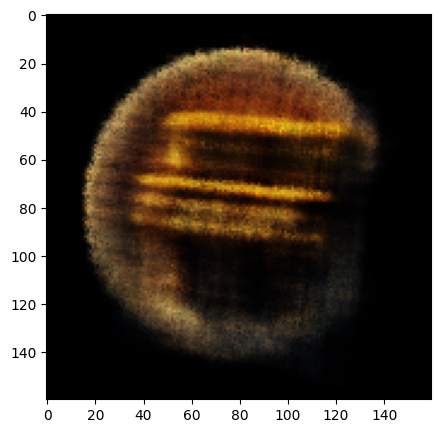

epoch: 1, loss=0.00232916684160009
epoch: 2, loss=0.0014770111304707825
epoch: 3, loss=0.0010978746570646763
epoch: 4, loss=0.0008813343738205731
epoch: 5, loss=0.0007284004624001682
epoch: 6, loss=0.0006226790625136346
epoch: 7, loss=0.0005383288233308122
epoch: 8, loss=0.000482251957943663
epoch: 9, loss=0.0004400023713009432


In [ ]:
# Цикл Оптимизации NeRF ####


radiance_field = VanillaNeRF().cuda()
optimizer = torch.optim.Adam(radiance_field.parameters(), lr=5e-4)
EPOCHS = 10

for epoch in range(EPOCHS):
    total_loss = 0
    for batch in dataloader:
        imv = batch["imv"].cuda()
        coords = batch["coords"].cuda()
        target = batch["img"].cuda().float()

        pred = render_radiance_field(
            imv, coords, radiance_field,
            dataset.focal, dataset.resolution,
            dataset.near, dataset.far,
            bins=64, train=True
        )

        loss = ((pred - target) ** 2).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"epoch: {epoch}, loss={avg_loss}")

    if epoch == 0:
        with torch.no_grad():
            img = render_radiance_field(
                dataset[0]["imv"].cuda(), None, radiance_field,
                dataset.focal, dataset.resolution,
                dataset.near, dataset.far, train=False
            )
            plt.figure(figsize=(5,5))
            plt.imshow(img.detach().cpu().numpy())
            plt.show()

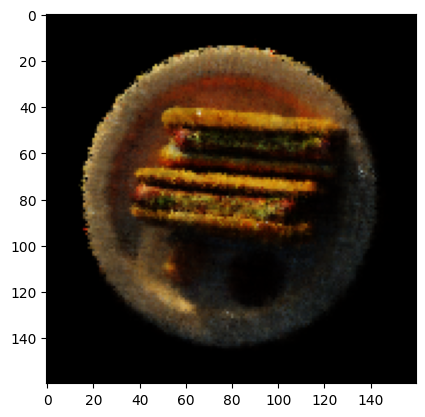

In [46]:
c = render_radiance_field(
    dataset[0]["imv"].cuda(),
    None,
    radiance_field,
    dataset.focal,
    dataset.resolution,
    dataset.near,
    dataset.far,
    train=False,
)
plt.imshow(c.detach().cpu());